In [7]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import StackingRegressor
from xgboost import XGBRegressor
import math
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from xgboost import XGBRegressor

In [8]:
import glob

### Does imputing  with missing values with spatial information from a nearby buoy (44095) improve forecasting at the target station

In [9]:
na_vals = [99, 999, 9999, 99999]

def read_ndbc_stdmet(path):
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        header = None
        for line in f:
            if line.startswith("#YY"):
                header = line.lstrip("#").strip().split()
                break
    if header is None:
        raise ValueError(f"Couldn't find #YY header in {path}")

    df = pd.read_csv(
        path,
        sep=r"\s+",
        comment="#",
        header=None,
        names=header,
        na_values=na_vals,
        engine="python",
    )
    return df

def build_station_df(station_prefix):
    files = sorted(glob.glob(f"{station_prefix}*.txt"))  
    dfs = [read_ndbc_stdmet(f) for f in files]
    df = pd.concat(dfs, ignore_index=True)

    # make datetime
    df = df.rename(columns={"YY":"year","MM":"month","DD":"day","hh":"hour","mm":"minute"})
    df["datetime"] = pd.to_datetime(df[["year","month","day","hour","minute"]], errors="coerce")
    df = df.dropna(subset=["datetime"]).set_index("datetime").sort_index()

    return df

target = build_station_df("41025h")   # target station
nbr    = build_station_df("44095h")   # nearby station


In [11]:
target.head()

,year,month,day,hour,minute,WDIR,WSPD,GST,WVHT,DPD,APD,MWD,PRES,ATMP,WTMP,DEWP,VIS,TIDE
datetime,,,,,,,,,,,,,,,,,,
2013-12-31 23:50:00,2013,12,31,23,50,305.0,7.0,10.0,0.96,5.56,4.41,2.0,1025.5,11.8,23.3,1.8,NaN,NaN
2014-01-01 00:50:00,2014,1,1,0,50,301.0,6.8,9.5,0.96,6.25,4.40,360.0,1026.6,11.8,23.3,1.4,NaN,NaN
2014-01-01 01:50:00,2014,1,1,1,50,305.0,7.5,9.5,0.89,5.88,4.23,2.0,1027.6,11.9,23.3,0.5,NaN,NaN
2014-01-01 02:50:00,2014,1,1,2,50,308.0,6.6,9.4,0.89,5.88,4.15,3.0,1027.9,11.7,23.3,-0.1,NaN,NaN
2014-01-01 03:50:00,2014,1,1,3,50,322.0,7.0,10.1,0.92,6.25,4.38,26.0,1027.9,12.0,23.2,-0.3,NaN,NaN


In [12]:
nbr.head()

,year,month,day,hour,minute,WDIR,WSPD,GST,WVHT,DPD,APD,MWD,PRES,ATMP,WTMP,DEWP,VIS,TIDE
datetime,,,,,,,,,,,,,,,,,,
2014-01-01 00:17:00,2014,1,1,0,17,NaN,NaN,NaN,0.93,5.88,4.22,28.0,NaN,NaN,14.0,NaN,NaN,NaN
2014-01-01 00:47:00,2014,1,1,0,47,NaN,NaN,NaN,0.90,6.67,4.13,48.0,NaN,NaN,14.0,NaN,NaN,NaN
2014-01-01 01:17:00,2014,1,1,1,17,NaN,NaN,NaN,0.88,6.25,4.25,45.0,NaN,NaN,14.0,NaN,NaN,NaN
2014-01-01 01:47:00,2014,1,1,1,47,NaN,NaN,NaN,0.80,6.25,4.06,44.0,NaN,NaN,14.0,NaN,NaN,NaN
2014-01-01 02:17:00,2014,1,1,2,17,NaN,NaN,NaN,0.81,6.67,4.09,57.0,NaN,NaN,14.0,NaN,NaN,NaN


In [14]:
target.isna().sum()

year           0
month          0
day            0
hour           0
minute         0
WDIR        4505
WSPD        1086
GST         1089
WVHT       73607
DPD        73607
APD        73607
MWD        73961
PRES         212
ATMP        8042
WTMP        5272
DEWP       17540
VIS       117882
TIDE      117882
dtype: int64

In [15]:
nbr.isna().sum()

year          0
month         0
day           0
hour          0
minute        0
WDIR      92715
WSPD      92715
GST       92715
WVHT          0
DPD           0
APD           0
MWD         860
PRES      92715
ATMP      92715
WTMP         76
DEWP      92715
VIS       92715
TIDE      92715
dtype: int64

## Wave Height

In [34]:
y_col = "WVHT"   # wave height target

In [35]:
target_h = target.resample("H").mean()
nbr_h    = nbr.resample("H").mean()

print(target_h.index.min(), target_h.index.max())
print(nbr_h.index.min(), nbr_h.index.max())


2013-12-31 23:00:00 2019-12-31 23:00:00
2014-01-01 00:00:00 2019-12-31 23:00:00


C:\Users\attafuro\AppData\Local\Temp\ipykernel_1152\169219894.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  target_h = target.resample("H").mean()
C:\Users\attafuro\AppData\Local\Temp\ipykernel_1152\169219894.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  nbr_h    = nbr.resample("H").mean()


In [36]:
df = target_h.add_suffix("_tgt").join(nbr_h.add_suffix("_nbr"), how="inner")

# Keep only relevant columns (you can add more later)
df = df[[f"{y_col}_tgt", f"{y_col}_nbr"]].copy()

df.head()


,WVHT_tgt,WVHT_nbr
datetime,,
2014-01-01 00:00:00,0.96,0.915
2014-01-01 01:00:00,0.89,0.840
2014-01-01 02:00:00,0.89,0.790
2014-01-01 03:00:00,0.92,0.735
2014-01-01 04:00:00,0.94,0.745


In [37]:
n = len(df)

train_size = int(0.7 * n)
val_size   = int(0.15 * n)

train_df = df.iloc[:train_size].copy()
val_df   = df.iloc[train_size:train_size + val_size].copy()
test_df  = df.iloc[train_size + val_size:].copy()

len(train_df), len(val_df), len(test_df)



(36808, 7887, 7889)

Missing observations at the target station were estimated using a regression-based spatial imputation approach, where relationships between neighboring and target stations were learned from historical data and applied only when the target observation was unavailable.

In [38]:
LAG = 1  # hours

for df_ in [train_df, val_df, test_df]:
    df_["WVHT_nbr_lag1"] = df_["WVHT_nbr"].shift(LAG)


In [39]:
train_df[["WVHT_tgt", "WVHT_nbr", "WVHT_nbr_lag1"]].head(5)


,WVHT_tgt,WVHT_nbr,WVHT_nbr_lag1
datetime,,,
2014-01-01 00:00:00,0.96,0.915,NaN
2014-01-01 01:00:00,0.89,0.840,0.915
2014-01-01 02:00:00,0.89,0.790,0.840
2014-01-01 03:00:00,0.92,0.735,0.790
2014-01-01 04:00:00,0.94,0.745,0.735


In [40]:
from sklearn.linear_model import LinearRegression

# Use only rows where both target and lagged neighbor exist
mask = (
    train_df["WVHT_tgt"].notna() &
    train_df["WVHT_nbr_lag1"].notna()
)

X_train = train_df.loc[mask, ["WVHT_nbr_lag1"]]
y_train = train_df.loc[mask, "WVHT_tgt"]

imp_model = LinearRegression()
imp_model.fit(X_train, y_train)

imp_model.coef_, imp_model.intercept_


(array([0.82657752]), 0.37098374848018567)

In [41]:
def impute_target(df, target_col, feature_col, model):
    df = df.copy()
    missing = df[target_col].isna() & df[feature_col].notna()
    df.loc[missing, target_col] = model.predict(df.loc[missing, [feature_col]])
    return df


In [42]:
train_imp = impute_target(train_df, "WVHT_tgt", "WVHT_nbr_lag1", imp_model)
val_imp   = impute_target(val_df,   "WVHT_tgt", "WVHT_nbr_lag1", imp_model)
test_imp  = impute_target(test_df,  "WVHT_tgt", "WVHT_nbr_lag1", imp_model)

In [43]:
train_df["WVHT_tgt"].isna().sum(), train_imp["WVHT_tgt"].isna().sum()


(4125, 1487)

Since we have that target is missing

neighbor is also missing

We handle this without leakage using a past rolling mean.

In [44]:
def fallback_past_rolling_mean(df, col, window=24):
    df = df.copy()
    roll = df[col].shift(1).rolling(window=window, min_periods=1).mean()
    df[col] = df[col].fillna(roll)
    return df


In [45]:
train_imp = fallback_past_rolling_mean(train_imp, "WVHT_tgt", 24)
val_imp   = fallback_past_rolling_mean(val_imp,   "WVHT_tgt", 24)
test_imp  = fallback_past_rolling_mean(test_imp,  "WVHT_tgt", 24)


In [46]:
train_imp["WVHT_tgt"].isna().sum(), val_imp["WVHT_tgt"].isna().sum(), test_imp["WVHT_tgt"].isna().sum()

(1381, 0, 1)

In [53]:
def missing_report(name, df_, col="WVHT_tgt"):
    n = len(df_)
    m = df_[col].isna().sum()
    print(f"{name:8s} | rows={n:6d} | missing={m:6d} | missing%={(m/n)*100:6.2f}%")

print("BEFORE imputation:")
missing_report("train", train_df)
missing_report("val",   val_df)
missing_report("test",  test_df)

print("\nAFTER imputation:")
missing_report("train", train_imp)
missing_report("val",   val_imp)
missing_report("test",  test_imp)


BEFORE imputation:
train    | rows= 36808 | missing=  4125 | missing%= 11.21%
val      | rows=  7887 | missing=  1351 | missing%= 17.13%
test     | rows=  7889 | missing=  2834 | missing%= 35.92%

AFTER imputation:
train    | rows= 36808 | missing=  1381 | missing%=  3.75%
val      | rows=  7887 | missing=     0 | missing%=  0.00%
test     | rows=  7889 | missing=     1 | missing%=  0.01%


Columns explained

start

The timestamp when the missing stretch begins

end

The timestamp when the missing stretch ends

duration_hours

The length of that missing stretch, measured in hours

In [54]:
def find_nan_gaps(df_, col="WVHT_tgt"):
    s = df_[col].isna().astype(int)
    change = s.diff().fillna(0)

    gap_starts = df_.index[change == 1]
    gap_ends   = df_.index[change == -1]

    # handle if series starts/ends with NaNs
    if s.iloc[0] == 1:
        gap_starts = gap_starts.insert(0, df_.index[0])
    if s.iloc[-1] == 1:
        gap_ends = gap_ends.append(pd.Index([df_.index[-1]]))

    gaps = pd.DataFrame({"start": gap_starts, "end": gap_ends})
    gaps["duration_hours"] = (gaps["end"] - gaps["start"]) / pd.Timedelta(hours=1)
    return gaps

gaps_train = find_nan_gaps(train_df, "WVHT_tgt")
gaps_val   = find_nan_gaps(val_df, "WVHT_tgt")
gaps_test  = find_nan_gaps(test_df, "WVHT_tgt")

print("Train gaps:", len(gaps_train))
print("Val gaps:", len(gaps_val))
print("Test gaps:", len(gaps_test))

gaps_train.head(10)


Train gaps: 480
Val gaps: 28
Test gaps: 24


,start,end,duration_hours
0,2014-01-02 01:00:00,2014-01-02 02:00:00,1.0
1,2014-01-02 14:00:00,2014-01-02 15:00:00,1.0
2,2014-01-03 03:00:00,2014-01-03 04:00:00,1.0
3,2014-01-03 08:00:00,2014-01-03 09:00:00,1.0
4,2014-01-05 20:00:00,2014-01-05 22:00:00,2.0
5,2014-01-06 01:00:00,2014-01-25 20:00:00,475.0
6,2014-01-26 07:00:00,2014-01-26 08:00:00,1.0
7,2014-01-27 00:00:00,2014-01-27 01:00:00,1.0
8,2014-01-27 04:00:00,2014-01-27 05:00:00,1.0
9,2014-01-27 18:00:00,2014-01-27 19:00:00,1.0


In [55]:
gaps_train.sort_values("duration_hours", ascending=False).head(15)

,start,end,duration_hours
230,2015-02-07 02:00:00,2015-04-06 15:00:00,1405.0
5,2014-01-06 01:00:00,2014-01-25 20:00:00,475.0
38,2014-02-19 18:00:00,2014-03-11 12:00:00,474.0
42,2014-03-13 03:00:00,2014-03-28 00:00:00,357.0
66,2014-04-11 18:00:00,2014-04-20 06:00:00,204.0
405,2017-04-06 12:00:00,2017-04-14 12:00:00,192.0
250,2015-07-22 03:00:00,2015-07-29 18:00:00,183.0
72,2014-04-24 13:00:00,2014-04-28 13:00:00,96.0
469,2017-11-07 11:00:00,2017-11-09 19:00:00,56.0
20,2014-02-11 09:00:00,2014-02-13 06:00:00,45.0


In [64]:
train_imp = train_imp.dropna(subset=["WVHT_tgt"])
val_imp   = val_imp.dropna(subset=["WVHT_tgt"])
test_imp  = test_imp.dropna(subset=["WVHT_tgt"])

## Wave Height Prediction

In [75]:
target_h_all = target.resample("H").mean()

# add suffix so it's clear these are from target station
target_h_all = target_h_all.add_suffix("_tgt")

target_h_all.head()


C:\Users\attafuro\AppData\Local\Temp\ipykernel_1152\152037311.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  target_h_all = target.resample("H").mean()


,year_tgt,month_tgt,day_tgt,hour_tgt,minute_tgt,WDIR_tgt,WSPD_tgt,GST_tgt,WVHT_tgt,DPD_tgt,APD_tgt,MWD_tgt,PRES_tgt,ATMP_tgt,WTMP_tgt,DEWP_tgt,VIS_tgt,TIDE_tgt
datetime,,,,,,,,,,,,,,,,,,
2013-12-31 23:00:00,2013.0,12.0,31.0,23.0,50.0,305.0,7.0,10.0,0.96,5.56,4.41,2.0,1025.5,11.8,23.3,1.8,NaN,NaN
2014-01-01 00:00:00,2014.0,1.0,1.0,0.0,50.0,301.0,6.8,9.5,0.96,6.25,4.40,360.0,1026.6,11.8,23.3,1.4,NaN,NaN
2014-01-01 01:00:00,2014.0,1.0,1.0,1.0,50.0,305.0,7.5,9.5,0.89,5.88,4.23,2.0,1027.6,11.9,23.3,0.5,NaN,NaN
2014-01-01 02:00:00,2014.0,1.0,1.0,2.0,50.0,308.0,6.6,9.4,0.89,5.88,4.15,3.0,1027.9,11.7,23.3,-0.1,NaN,NaN
2014-01-01 03:00:00,2014.0,1.0,1.0,3.0,50.0,322.0,7.0,10.1,0.92,6.25,4.38,26.0,1027.9,12.0,23.2,-0.3,NaN,NaN


In [76]:
wvht_imputed_all = (
    pd.concat([
        train_imp[["WVHT_tgt"]],
        val_imp[["WVHT_tgt"]],
        test_imp[["WVHT_tgt"]]
    ])
    .sort_index()
)


In [77]:
model_df = target_h_all.copy()

# overwrite raw WVHT with imputed WVHT
model_df["WVHT_tgt"] = wvht_imputed_all["WVHT_tgt"]

model_df.head()


,year_tgt,month_tgt,day_tgt,hour_tgt,minute_tgt,WDIR_tgt,WSPD_tgt,GST_tgt,WVHT_tgt,DPD_tgt,APD_tgt,MWD_tgt,PRES_tgt,ATMP_tgt,WTMP_tgt,DEWP_tgt,VIS_tgt,TIDE_tgt
datetime,,,,,,,,,,,,,,,,,,
2013-12-31 23:00:00,2013.0,12.0,31.0,23.0,50.0,305.0,7.0,10.0,NaN,5.56,4.41,2.0,1025.5,11.8,23.3,1.8,NaN,NaN
2014-01-01 00:00:00,2014.0,1.0,1.0,0.0,50.0,301.0,6.8,9.5,0.96,6.25,4.40,360.0,1026.6,11.8,23.3,1.4,NaN,NaN
2014-01-01 01:00:00,2014.0,1.0,1.0,1.0,50.0,305.0,7.5,9.5,0.89,5.88,4.23,2.0,1027.6,11.9,23.3,0.5,NaN,NaN
2014-01-01 02:00:00,2014.0,1.0,1.0,2.0,50.0,308.0,6.6,9.4,0.89,5.88,4.15,3.0,1027.9,11.7,23.3,-0.1,NaN,NaN
2014-01-01 03:00:00,2014.0,1.0,1.0,3.0,50.0,322.0,7.0,10.1,0.92,6.25,4.38,26.0,1027.9,12.0,23.2,-0.3,NaN,NaN


In [88]:
train = model_df.loc[train_imp.index.min():train_imp.index.max()].copy()
val   = model_df.loc[val_imp.index.min():val_imp.index.max()].copy()
test  = model_df.loc[test_imp.index.min():test_imp.index.max()].copy()

In [95]:
TARGET = "WVHT_tgt"
EXOG_FEATURES = ["DPD_tgt","WSPD_tgt","GST_tgt","PRES_tgt"]

print("Train missingness BEFORE filling:")
print(train[[TARGET] + EXOG_FEATURES].isna().sum())

print("\nVal missingness BEFORE filling:")
print(val[[TARGET] + EXOG_FEATURES].isna().sum())

print("\nTest missingness BEFORE filling:")
print(test[[TARGET] + EXOG_FEATURES].isna().sum())


Train missingness BEFORE filling:
WVHT_tgt    1381
DPD_tgt     3249
WSPD_tgt    4252
GST_tgt     4252
PRES_tgt    3318
dtype: int64

Val missingness BEFORE filling:
WVHT_tgt       0
DPD_tgt     1253
WSPD_tgt    1251
GST_tgt     1251
PRES_tgt    1251
dtype: int64

Test missingness BEFORE filling:
WVHT_tgt       0
DPD_tgt     2777
WSPD_tgt    2752
GST_tgt     2752
PRES_tgt    2752
dtype: int64


In [96]:
def fill_past_only(df, cols, window=24):
    df = df.copy()
    for c in cols:
        df[c] = df[c].fillna(df[c].shift(1).rolling(window, min_periods=1).mean())
    return df

train = fill_past_only(train, EXOG_FEATURES, window=24)
val   = fill_past_only(val,   EXOG_FEATURES, window=24)
test  = fill_past_only(test,  EXOG_FEATURES, window=24)


In [97]:
import pandas as pd

def make_lags_fast(df, cols, n_lags):
    lagged = {}
    for col in cols:
        for lag in range(1, n_lags + 1):
            lagged[f"{col}_lag{lag}"] = df[col].shift(lag)
    return pd.DataFrame(lagged, index=df.index)

N_LAGS = 24
BASE_COLS = [TARGET] + EXOG_FEATURES

train_lags = make_lags_fast(train, BASE_COLS, N_LAGS)
val_lags   = make_lags_fast(val,   BASE_COLS, N_LAGS)
test_lags  = make_lags_fast(test,  BASE_COLS, N_LAGS)


In [98]:
def build_supervised(df, lags_df, target):
    out = pd.concat([df[[target]], lags_df], axis=1)
    out = out.dropna(subset=lags_df.columns.tolist() + [target])
    return out

train_sup = build_supervised(train, train_lags, TARGET)
val_sup   = build_supervised(val,   val_lags,   TARGET)
test_sup  = build_supervised(test,  test_lags,  TARGET)

len(train_sup), len(val_sup), len(test_sup)


(32399, 6638, 5088)

In [99]:
FEATURES = train_lags.columns.tolist()

X_train, y_train = train_sup[FEATURES], train_sup[TARGET]
X_val,   y_val   = val_sup[FEATURES],   val_sup[TARGET]
X_test,  y_test  = test_sup[FEATURES],  test_sup[TARGET]


In [100]:
print("Feature count:", len(FEATURES))
print("X_train shape:", X_train.shape)
print("NaNs in X_train:", X_train.isna().sum().sum())


Feature count: 120
X_train shape: (32399, 120)
NaNs in X_train: 0


In [101]:
train[[TARGET]+EXOG_FEATURES].isna().sum()

WVHT_tgt    1381
DPD_tgt     3010
WSPD_tgt    4013
GST_tgt     4013
PRES_tgt    3103
dtype: int64

In [102]:
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import StackingRegressor

from xgboost import XGBRegressor

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def eval_and_store(model, Xtr, ytr, Xte, yte, name, results):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    results.append({
        "model": name,
        "MAE": mean_absolute_error(yte, pred),
        "RMSE": rmse(yte, pred)
    })
    return pred


In [103]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)


In [104]:
results = []

# LR
lr = LinearRegression()
pred_lr = eval_and_store(lr, X_train_s, y_train, X_test_s, y_test, "LR", results)

# KNN
knn = KNeighborsRegressor(n_neighbors=10)
pred_knn = eval_and_store(knn, X_train_s, y_train, X_test_s, y_test, "KNN", results)

# DT (no scaling)
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
pred_dt = eval_and_store(dt, X_train, y_train, X_test, y_test, "DT", results)

# XGB
xgb = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
pred_xgb = eval_and_store(xgb, X_train, y_train, X_test, y_test, "XGB", results)

# XGBDT (stack DT + XGB then linear final)
xgbdt = StackingRegressor(
    estimators=[
        ("dt", DecisionTreeRegressor(max_depth=8, random_state=42)),
        ("xgb", xgb)
    ],
    final_estimator=LinearRegression()
)
pred_xgbdt = eval_and_store(xgbdt, X_train, y_train, X_test, y_test, "XGBDT", results)

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df


C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

,model,MAE,RMSE
0,LR,0.090112,0.145456
2,DT,0.102811,0.176512
4,XGBDT,0.096643,0.192060
3,XGB,0.097650,0.199464
1,KNN,0.225322,0.336377


Best model: LR


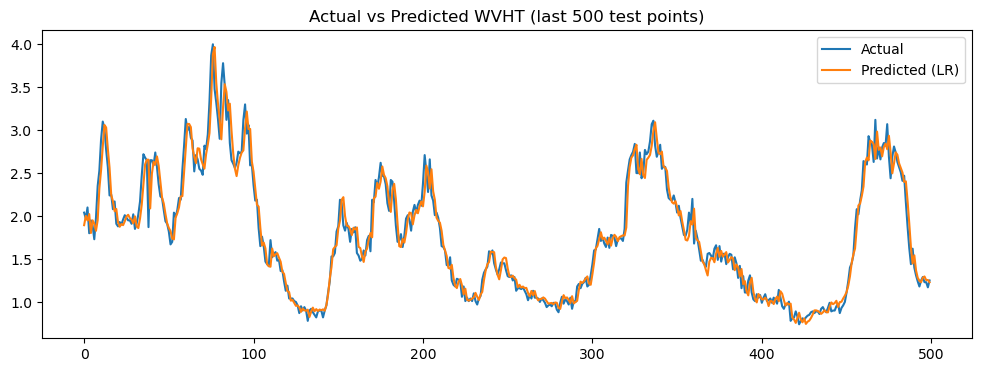

In [105]:
import matplotlib.pyplot as plt

# pick best by RMSE
best_name = results_df.iloc[0]["model"]
print("Best model:", best_name)

pred_map = {
    "LR": pred_lr,
    "KNN": pred_knn,
    "DT": pred_dt,
    "XGB": pred_xgb,
    "XGBDT": pred_xgbdt
}
best_pred = pred_map[best_name]

# plot last N points for clarity
N = 500
plt.figure(figsize=(12,4))
plt.plot(y_test.values[-N:], label="Actual")
plt.plot(best_pred[-N:], label=f"Predicted ({best_name})")
plt.title(f"Actual vs Predicted WVHT (last {N} test points)")
plt.legend()
plt.show()


## LSTM

In [109]:
import numpy as np

print("NaNs in X_train_lstm:", np.isnan(X_train_lstm_s).sum())
print("NaNs in X_val_lstm:",   np.isnan(X_val_lstm_s).sum())
print("NaNs in X_test_lstm:",  np.isnan(X_test_lstm_s).sum())

print("NaNs in y_train:", np.isnan(y_train_lstm).sum())
print("NaNs in y_val:",   np.isnan(y_val_lstm).sum())
print("NaNs in y_test:",  np.isnan(y_test_lstm).sum())


NaNs in X_train_lstm: 372480
NaNs in X_val_lstm: 114216
NaNs in X_test_lstm: 263112
NaNs in y_train: 1381
NaNs in y_val: 0
NaNs in y_test: 0


In [111]:
cols_needed = [TARGET] + EXOG_FEATURES

train_clean = train[cols_needed].dropna().copy()
val_clean   = val[cols_needed].dropna().copy()
test_clean  = test[cols_needed].dropna().copy()

X_train_lstm, y_train_lstm = make_sequences(train_clean, TARGET, EXOG_FEATURES, N_LAGS)
X_val_lstm,   y_val_lstm   = make_sequences(val_clean,   TARGET, EXOG_FEATURES, N_LAGS)
X_test_lstm,  y_test_lstm  = make_sequences(test_clean,  TARGET, EXOG_FEATURES, N_LAGS)


In [112]:
from sklearn.preprocessing import StandardScaler

scaler_lstm = StandardScaler()
n_tr, t_tr, f_tr = X_train_lstm.shape

X_train_lstm_s = scaler_lstm.fit_transform(X_train_lstm.reshape(-1, f_tr)).reshape(n_tr, t_tr, f_tr)
X_val_lstm_s   = scaler_lstm.transform(X_val_lstm.reshape(-1, f_tr)).reshape(X_val_lstm.shape)
X_test_lstm_s  = scaler_lstm.transform(X_test_lstm.reshape(-1, f_tr)).reshape(X_test_lstm.shape)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

lstm_model = Sequential([
    LSTM(64, input_shape=(N_LAGS, f_tr)),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mse")

es = EarlyStopping(patience=5, restore_best_weights=True)

lstm_model.fit(
    X_train_lstm_s, y_train_lstm,
    validation_data=(X_val_lstm_s, y_val_lstm),
    epochs=50,
    batch_size=32,
    callbacks=[es],
    verbose=1
)

pred_lstm = lstm_model.predict(X_test_lstm_s).ravel()
lstm_mae  = mean_absolute_error(y_test_lstm, pred_lstm)
lstm_rmse = rmse(y_test_lstm, pred_lstm)

print(f"LSTM | MAE={lstm_mae:.3f} | RMSE={lstm_rmse:.3f}")


Epoch 1/50


C:\Users\attafuro\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1020/1020 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.2502 - val_loss: 0.0239
Epoch 2/50
1020/1020 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0380 - val_loss: 0.0224
Epoch 3/50
1020/1020 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.0341 - val_loss: 0.0195
Epoch 4/50
 371/1020 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0333

In [ ]:
results_df = pd.concat(
    [results_df, pd.DataFrame([{"model":"LSTM", "MAE":lstm_mae, "RMSE":lstm_rmse}])],
    ignore_index=True
).sort_values("RMSE")

results_df
